In [78]:
from sklearn . cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [80]:
df = pd.read_csv(r"C:\Users\Rajesh\Desktop\Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [82]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None


In [84]:
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [86]:
df.shape

(440, 8)

In [88]:
df.Channel

0      2
1      2
2      2
3      1
4      2
      ..
435    1
436    1
437    2
438    1
439    1
Name: Channel, Length: 440, dtype: int64

In [90]:
array=df.values

In [92]:
array

array([[    2,     3, 12669, ...,   214,  2674,  1338],
       [    2,     3,  7057, ...,  1762,  3293,  1776],
       [    2,     3,  6353, ...,  2405,  3516,  7844],
       ...,
       [    2,     3, 14531, ...,   437, 14841,  1867],
       [    1,     3, 10290, ...,  1038,   168,  2125],
       [    1,     3,  2787, ...,    65,   477,    52]], dtype=int64)

In [94]:
stscaler = StandardScaler().fit(array)
x = stscaler.transform(array)

In [96]:
x

array([[ 1.44865163,  0.59066829,  0.05293319, ..., -0.58936716,
        -0.04356873, -0.06633906],
       [ 1.44865163,  0.59066829, -0.39130197, ..., -0.27013618,
         0.08640684,  0.08915105],
       [ 1.44865163,  0.59066829, -0.44702926, ..., -0.13753572,
         0.13323164,  2.24329255],
       ...,
       [ 1.44865163,  0.59066829,  0.20032554, ..., -0.54337975,
         2.51121768,  0.12145607],
       [-0.69029709,  0.59066829, -0.13538389, ..., -0.41944059,
        -0.56977032,  0.21304614],
       [-0.69029709,  0.59066829, -0.72930698, ..., -0.62009417,
        -0.50488752, -0.52286938]])

In [98]:
import scipy.cluster.hierarchy as sch

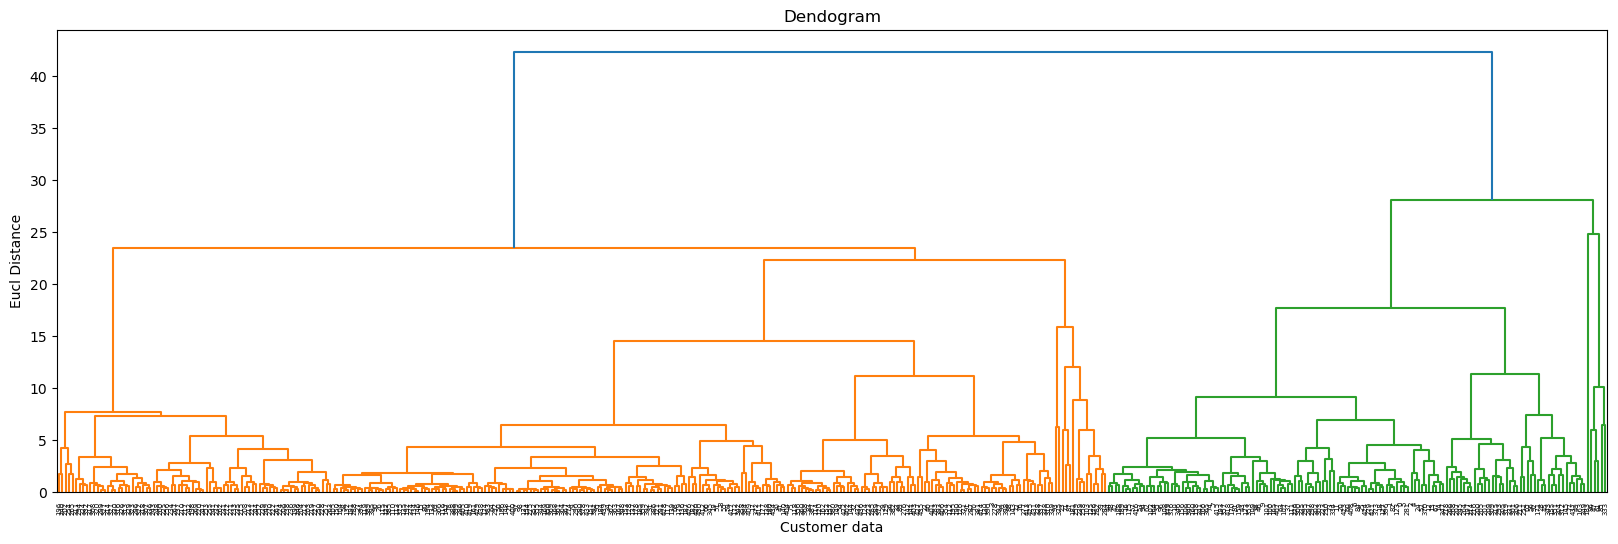

In [100]:
plt.figure(figsize=(20,6))
dendo = sch.dendrogram(sch.linkage(x,method='ward'))
plt.title('Dendogram')
plt.xlabel('Customer data')
plt.ylabel('Eucl Distance')
plt.show()
                            

In [101]:
len(set(dendo['color_list']))

3

In [102]:
from sklearn.cluster import AgglomerativeClustering

In [103]:
group=AgglomerativeClustering(n_clusters=100)
group.fit_predict(x)

array([67, 67, 88,  7, 37, 67, 29,  2, 10, 45, 85, 29,  5,  5,  5,  0, 22,
       61, 38, 10, 29, 74, 57, 91, 37, 29,  4,  4, 28, 54, 52, 15, 18, 33,
       16, 39, 33, 27, 45, 97, 57, 52, 47,  9, 47, 28, 45, 53, 47, 34, 74,
       10, 56, 22, 18, 10,  6, 22,  4, 10, 29, 71, 39, 27, 74, 55, 10,  5,
       14,  0, 23, 64,  7, 81,  2, 40,  7, 34,  0, 16,  0,  9, 67, 40, 29,
       83, 95, 60,  7, 33,  4, 23,  6, 87, 22, 16, 39, 16, 16,  7, 27, 45,
       39, 96,  4,  4,  2, 27, 39, 58,  4, 27, 23,  4, 40,  4,  0, 15, 40,
        4, 40, 15,  4, 67, 48, 92, 23, 38, 15, 54,  7, 16,  4,  0,  0,  0,
       14, 15, 52, 15, 52, 11, 11,  7, 18, 62,  0,  0, 74, 18,  4, 16, 40,
       15, 16,  8,  2, 40,  2,  9,  2,  0, 40, 34, 39, 27,  2, 16, 16, 16,
        9, 28, 10,  9, 74, 22, 76, 52, 15, 14, 52, 59, 17, 63, 16, 15, 74,
       14, 47, 22, 23,  4,  0, 93,  0, 23, 94, 21, 13, 43, 30, 30, 31, 43,
       43, 30, 43, 21, 19, 30, 13, 36, 43, 19, 21, 19, 77, 13, 68, 43, 13,
       19, 51, 50, 43, 80

In [104]:
cluster = group.fit_predict(x)
cluster.shape

(440,)

In [105]:
from sklearn.metrics import silhouette_score
silhouette_score(x,cluster)

0.22586694276975647

In [106]:
x

array([[ 1.44865163,  0.59066829,  0.05293319, ..., -0.58936716,
        -0.04356873, -0.06633906],
       [ 1.44865163,  0.59066829, -0.39130197, ..., -0.27013618,
         0.08640684,  0.08915105],
       [ 1.44865163,  0.59066829, -0.44702926, ..., -0.13753572,
         0.13323164,  2.24329255],
       ...,
       [ 1.44865163,  0.59066829,  0.20032554, ..., -0.54337975,
         2.51121768,  0.12145607],
       [-0.69029709,  0.59066829, -0.13538389, ..., -0.41944059,
        -0.56977032,  0.21304614],
       [-0.69029709,  0.59066829, -0.72930698, ..., -0.62009417,
        -0.50488752, -0.52286938]])

In [107]:
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

wcss=[]
for i in range (2,11):
    kmeans=KMeans(n_clusters=4,init='k-means++',random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

In [108]:
wcss

[1851.8408722743848,
 1851.8408722743848,
 1851.8408722743848,
 1851.8408722743848,
 1851.8408722743848,
 1851.8408722743848,
 1851.8408722743848,
 1851.8408722743848,
 1851.8408722743848]

Text(0.5, 1.0, 'The Elbow Method')

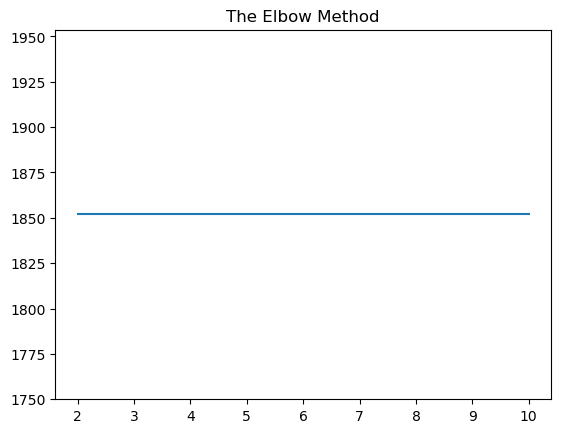

In [109]:
plt.plot(range(2,11),wcss)
plt.title('The Elbow Method')
         

In [110]:
group_num=pd.DataFrame(cluster,columns=['Group'])
group_num

,Group
0,67
1,67
2,88
3,7
4,37
...,...
435,20
436,48
437,34
438,0


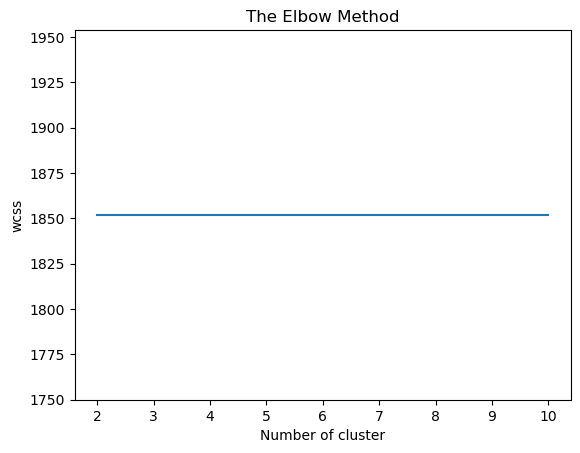

In [121]:
import matplotlib.pyplot as plt
plt.plot(range(2,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of cluster')
plt.ylabel('wcss')
plt.show()

In [129]:
model = KMeans(n_clusters = 4, random_state = 309)
groups =  model.fit_predict(x)

In [131]:
groups

array([0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2,
       2, 3, 0, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 2, 2, 2, 0, 0,
       0, 0, 0, 3, 0, 0, 2, 2, 0, 0, 2, 2, 0, 0, 2, 2, 0, 3, 0, 0, 2, 0,
       2, 0, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2, 2, 2, 0, 0, 2, 0, 3, 3, 2,
       2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0,
       2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 2, 0, 2, 0,
       2, 2, 2, 2, 2, 3, 2, 3, 2, 2, 2, 2, 0, 0, 2, 2, 2, 0, 2, 2, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 1, 0, 1, 0, 0, 1, 0,